### DG rectangular mesh testing w. $L^2$-projection

##### 1) DG rectangular mesh function (uniform quads)
Let the physical domain be
$$
    \Omega = [x_{\min}, x_{\max}] \times [y_{\min}, y_{\max}]
$$

We split $\Omega$ into $K_x \times K_y$ uniform rectangles by introducing the grid edges
$$
    x_{\text{edges}} = \{ x_0,\ldots, x_{K_x} \}, \quad y_{\text{edges}} = \{ y_0,\ldots, y_{K_y} \}
$$
with $x_0=x_{\min}$, $x_{K_x}=x_{\max}$ and analogously in the $y$-direction.

Each element 
$$
K_e = [x_e, x_{e+1}]\times [y_e, y_{e+1}]
$$ 
is an affine image of the reference square $\hat K = [-1,1]^2$:
$$
    x = x_e + \frac{x_{e+1}-x_e}{2}(r+1), \quad y = y_e + \frac{y_{e+1}-y_e}{2}(s+1)
$$
where $(r,s) \in [-1,1]^2$ and $(x_e,y_e)$ denotes the lower-left corner of element $e$.

For a uniform mesh we have:
$$
    h_x = x_{e+1}-x_e = \frac{x_{\max}-x_{\min}}{K_x}, \quad h_y = y_{e+1}-y_e = \frac{y_{\max}-y_{\min}}{K_y}
$$

The Jacobian determinant of the affine mapping is constant:
\begin{align*}
|J|
&= \Big| \det
\begin{bmatrix}
\frac{\partial x}{\partial r} & \frac{\partial x}{\partial s} \\
\frac{\partial y}{\partial r} & \frac{\partial y}{\partial s}
\end{bmatrix} \Big|
= \Big| \det
\begin{bmatrix}
\frac{x_{e+1}-x_e}{2} & 0 \\
0 & \frac{y_{e+1}-y_e}{2}
\end{bmatrix} \Big|
= \frac{h_x h_y}{4}.
\end{align*}

##### $L^2$ projection math (elementwise)

We have a DG space on each element
$$
    V_h(K_e) = \mathbb{Q}^p=\text{span}\{ \phi_{ij}(r,s) \}_{i,j=0}^p
$$
with orthonormal basis on $[-1,1]$:
$$
    \ell_n = \sqrt{\frac{2n+1}{2}} P_n(r)
$$
where $P_n$ is the Legendre polynomial of degree $n$. On the reference element $\hat K$ we define
$$
    \phi_{ij}(r,s) = \ell_i(r)\ell_j(s)
$$
which satisfy
$$
    \int_{\hat K}\phi_{ij}(r,s)\phi_{mn}(r,s)\,dr\,ds = \delta_{im}\delta_{jn}
$$

The elementwise $L^2$ projection solves:
$$
    \int_{K_e} u_h\,v\,dx\,dy = \int_{K_e} f\,v\,dx\,dy, \quad \forall v\in V_h(K_e)
$$
Now, taking $v=\phi_{mn}$ and using orthonormality with the affine map yields:
$$
    c_{mn}^{(e)} = \int_{\hat K} f\big( x(r), y(s) \big)\,\phi_{mn}(r,s)\,dr\,ds
$$

Thus, the DG coefficients are given by inner products on the reference element, which are evaluated numerically using suitable quadrature rules.

##### **Problem**: What is $f(x,y)$ when we have a grid of pixels?

If we have samples on a grid $\{(x_i,y_i)\}$ with values $f_{i,j}$. 

A standard choice is to treat $f(x,y)$ as the bilinear interpolant of the pixel grid and evaluate that interpolant at quadrature points. 

Another choice is to represent the data as a piecewise constant function over each pixel.

### Elementwise $L^2$ projection onto a DG modal basis

Let $f(x,y)$ be the bilinear interpolant of the discrete image data
$\{f_{ij}\}$ defined on a Cartesian grid $(x_i,y_j)$.

The physical domain $\Omega$ is decomposed into uniform rectangular elements
$$
K_{e} = [x_e,x_{e+1}]\times[y_e,y_{e+1}],
$$
where $\{x_e\}_{e=0}^{K_x}$ and $\{y_e\}_{e=0}^{K_y}$ denote the grid edges.

Each element is mapped affinely from the reference square $\hat K=[-1,1]^2$ via
$$
x(r) = x_e + \tfrac{h_x}{2}(r+1), \qquad
y(s) = y_e + \tfrac{h_y}{2}(s+1).
$$

On $\hat K$, we use the tensor-product orthonormal Legendre basis
$$
\phi_{ij}(r,s) = \ell_i(r)\,\ell_j(s), \qquad
\ell_n(t) = \sqrt{\tfrac{2n+1}{2}}\,P_n(t),
$$
where $P_n$ is the Legendre polynomial of degree $n$.

The DG approximation on each element is
$$
u_h|_{K_e}(x,y) = \sum_{i=0}^p \sum_{j=0}^p c_{ij}^{(e)} \,\phi_{ij}(r,s).
$$

The elementwise $L^2$ projection satisfies
$$
c_{ij}^{(e)} = \int_{\hat K} f(x(r),y(s))\,\phi_{ij}(r,s)\,dr\,ds.
$$

Using tensor-product Gauss–Legendre quadrature with nodes
$\{r_a,w_a\}_{a=1}^{n_q}$ and $\{s_b,v_b\}_{b=1}^{n_q}$, this integral is
approximated by
$$
c_{ij}^{(e)} \approx
\sum_{b=1}^{n_q}\sum_{a=1}^{n_q}
v_b\,w_a\,
f\!\left(x(r_a),y(s_b)\right)\,
\ell_i(r_a)\,\ell_j(s_b).
$$

The fast implementation evaluates the same expression by first summing in the
$r$-direction and then in the $s$-direction.


### Reconstruction of a DG modal field on a Cartesian grid

Given modal coefficients $c^{(e)}_{mn}$ on each element $K_e$, define
$$
u_h|_{K_e}(x,y) = \sum_{m=0}^p\sum_{n=0}^p c^{(e)}_{mn}\,\ell_m(r)\,\ell_n(s),
$$
where $(r,s)\in[-1,1]^2$ are reference coordinates obtained from
$$
r = 2\frac{x-x_e}{h_x}-1,\qquad s = 2\frac{y-y_e}{h_y}-1.
$$
To evaluate on a Cartesian grid $\{(x_i,y_j)\}\subset\Omega$, assign each
$(x_i,y_j)$ to the unique element by the rule:
left/bottom edges included, right/top excluded (except global boundary),
then compute $u_h(x_i,y_j)$ by the formula above.


### Testing on Shepp-Logan Phantom

In [1]:
import odl
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("..")



(-0.5, 99.5, 99.5, -0.5)

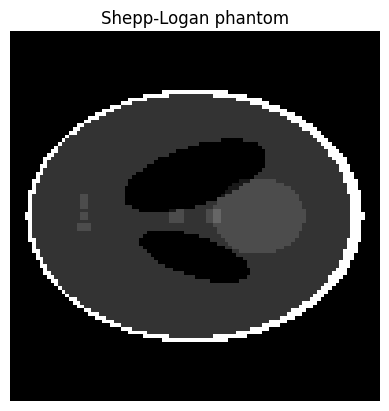

In [2]:

xmin, xmax, ymin, ymax = -1, 1, -1, 1
domain = [xmin, xmax, ymin, ymax]


space = odl.uniform_discr(
    min_pt=[xmin, ymin],
    max_pt=[xmax, ymax],
    shape=[100, 100],
    dtype='float32'
)

phantom = odl.phantom.shepp_logan(space, modified=True)
plt.imshow(phantom, cmap='gray')
plt.title("Shepp-Logan phantom")
plt.axis("off")


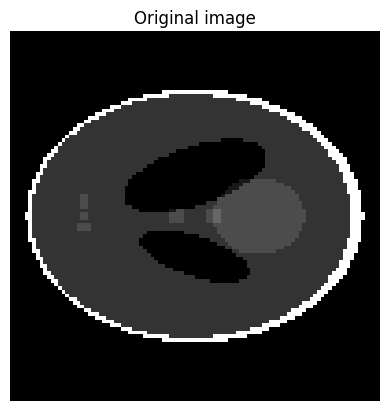

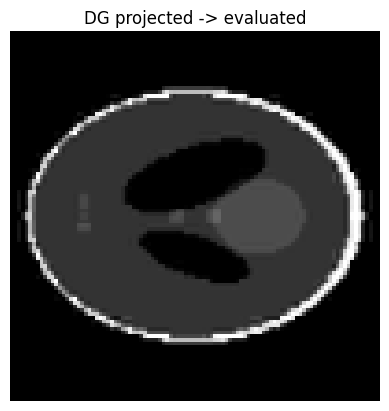

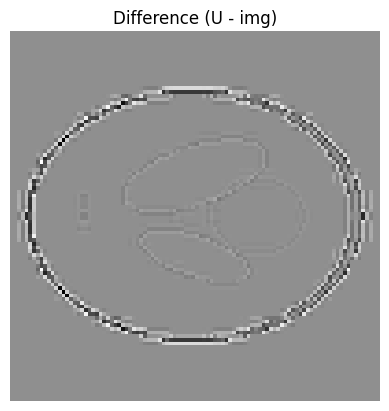

relative L2 error:  2.105e-01
gradient error:     3.184e-01


In [3]:

from src.dg_l2_projection import l2_project_image_to_dg
from src.dg_utils import eval_dg_modal_on_img_grid
from src.metrics import rel_l2_err, gradient_error

#### Testing the bilinear interpolator case ####
img = phantom.asarray()
Ny, Nx = img.shape
# dx, dy = space.cell_sides

# DG Stuff
# currently I have not implemented an evaluation for arbitrary grid. Focus lies on the nodal --> modal code. 
# Therefore for accurate evaluation we require the relationship K_j * (p + 1) = DOF_j, for j ={x,y}

# DG stuff
p = 2
order = p + 1

DOF_x, DOF_y = 120, 120     # 5! for both
Kx = int(DOF_x / order)
Ky = int(DOF_y / order)

# Now set size of phantom (space).
space = odl.uniform_discr(
    min_pt=[xmin, ymin],
    max_pt=[xmax, ymax],
    shape=[DOF_x, DOF_y],
    dtype='float32'
)

phantom = odl.phantom.shepp_logan(space, modified=True)

dg_bilinear = l2_project_image_to_dg(recon=img, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=p, mode="bilinear", Kx=Kx, Ky=Ky)

U_bilinear = eval_dg_modal_on_img_grid(dg_bilinear)

# Plot both 

vmin = 0
vmax = 1

plt.figure()
plt.imshow(img, cmap="gray", vmax=vmax, vmin=vmin)
plt.title("Original image")
plt.axis("off")

plt.figure()
plt.imshow(U_bilinear, cmap="gray", vmax=vmax, vmin=vmin)
plt.title("DG projected -> evaluated")
plt.axis("off")

plt.figure()
plt.imshow(U_bilinear - img, cmap="gray")
plt.title("Difference (U - img)")
plt.axis("off")
plt.show()


dx, dy = dg_bilinear["dx"], dg_bilinear["dy"]

l2_err_bilinear = rel_l2_err(x=U_bilinear, xtrue=img)
grad_err_bilinear = gradient_error(x=U_bilinear, xtrue=img, dx=dx, dy=dy)

print(f"relative L2 error:  {l2_err_bilinear:.3e}")
print(f"gradient error:     {grad_err_bilinear:.3e}")

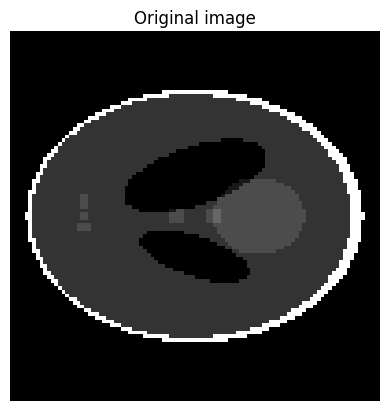

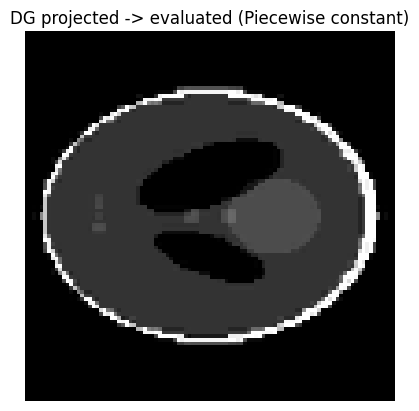

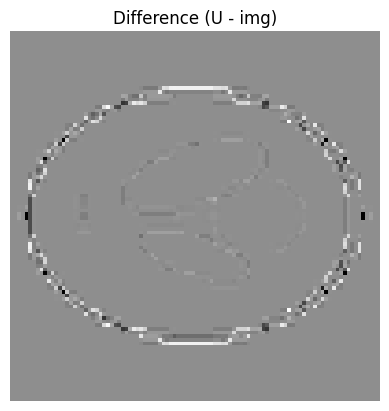

Elements used: (Kx, Ky) = (40, 40), polynomial degree = 2

Piecewise constant error:    

relative L2 error:  1.747e-01
gradient error:     2.766e-01

Bilinear Interpolation error:    

relative L2 error:  2.105e-01
gradient error:     3.184e-01


In [4]:
#### Testing the piecewise constant case ####


dg_pwlinear = l2_project_image_to_dg(recon=img, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=p, mode="piecewise_constant", Kx=Kx, Ky=Ky)

U_pwlinear = eval_dg_modal_on_img_grid(dg_pwlinear)

# Plot both 

vmin = 0
vmax = 1

plt.figure()
plt.imshow(img, cmap="gray", vmax=vmax, vmin=vmin)
plt.title("Original image")
plt.axis("off")

plt.figure()
plt.imshow(U_pwlinear, cmap="gray", vmax=vmax, vmin=vmin)
plt.title("DG projected -> evaluated (Piecewise constant)")
plt.axis("off")

plt.figure()
plt.imshow(U_pwlinear - img, cmap="gray")
plt.title("Difference (U - img)")
plt.axis("off")
plt.show()


dx, dy = dg_pwlinear["dx"], dg_pwlinear["dy"]

l2_err_pwlinear = rel_l2_err(x=U_pwlinear, xtrue=img)
grad_err_pwlinear = gradient_error(x=U_pwlinear, xtrue=img, dx=dx, dy=dy)

print(f"Elements used: (Kx, Ky) = ({Kx}, {Ky}), polynomial degree = {p}\n")
print("Piecewise constant error:    \n")
print(f"relative L2 error:  {l2_err_pwlinear:.3e}")
print(f"gradient error:     {grad_err_pwlinear:.3e}")
print("\nBilinear Interpolation error:    \n")
print(f"relative L2 error:  {l2_err_bilinear:.3e}")
print(f"gradient error:     {grad_err_bilinear:.3e}")